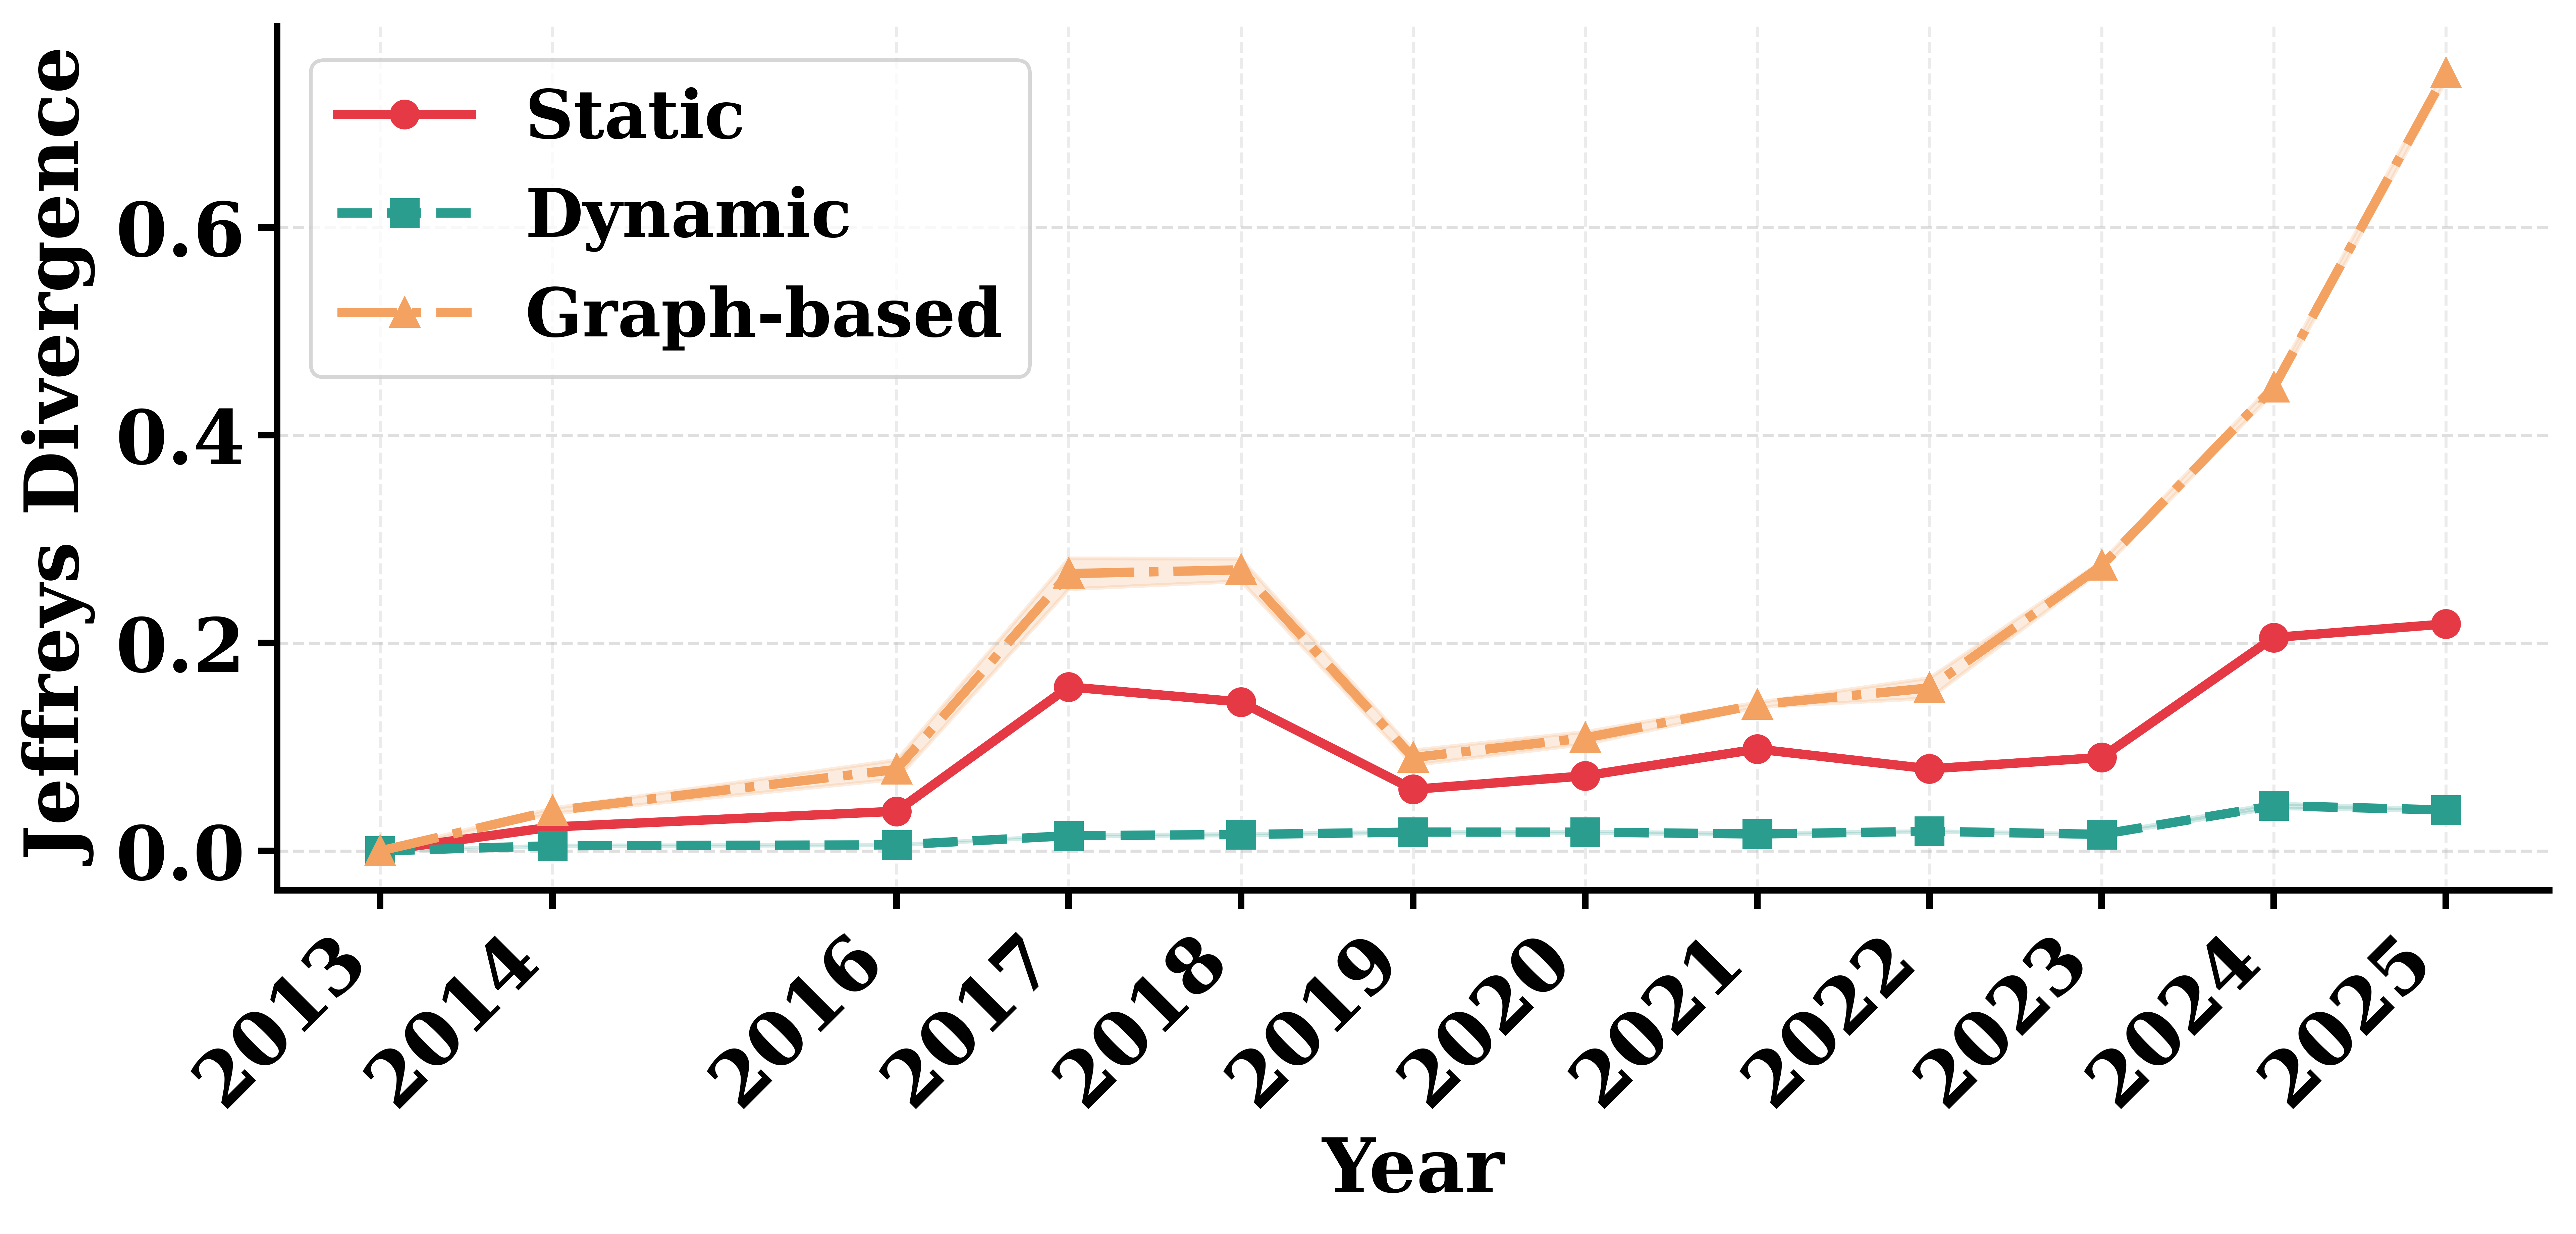

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import matplot2tikz

plt.rcParams.update({
    "figure.dpi": 800,
    "savefig.dpi": 800,
    "savefig.bbox": "tight",
    "font.family": "serif",
    "font.serif": "DejaVu Serif",
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 18,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "axes.labelweight": "bold",
    "font.weight": "bold",
})

ROOT = Path("malware_v2")

MODALITIES = {
    "data": "Static",
    "json": "Dynamic",
    "gml": "Graph-based"
}

COLORS = {
    "data": "#E63946",
    "json": "#2A9D8F",
    "gml": "#F4A261"
}

MARKERS = {
    "data": "o",
    "json": "s",
    "gml": "^"
}

LINESTYLES = {
    "data": "-",
    "json": "--",
    "gml": "-."
}

def load_runs(modality):
    runs = []
    for i in [1, 2, 3]:
        path = ROOT / f"drift_{modality}_malware_run{i}.csv"
        df = pd.read_csv(path)
        runs.append(df)
    return runs

def compute_stats(runs):
    df_merged = runs[0][["year", "mean_divergence"]].rename(
        columns={"mean_divergence": "run1"}
    )

    for i, df in enumerate(runs[1:], start=2):
        df_merged[f"run{i}"] = df["mean_divergence"]
    df_merged["mean"] = df_merged[[f"run{i}" for i in range(1, 4)]].mean(axis=1)
    df_merged["std"]  = df_merged[[f"run{i}" for i in range(1, 4)]].std(axis=1)

    return df_merged.sort_values("year")

fig, ax = plt.subplots(figsize=(10, 5))

for modality in MODALITIES:
    runs = load_runs(modality)
    stats = compute_stats(runs)

    years = stats["year"]
    mean  = stats["mean"]
    std   = stats["std"]
    ax.plot(
        years,
        mean,
        label=MODALITIES[modality],
        color=COLORS[modality],
        marker=MARKERS[modality],
        linestyle=LINESTYLES[modality],
        linewidth=2.5,
        markersize=7
    )

    ax.fill_between(
        years,
        mean - std,
        mean + std,
        color=COLORS[modality],
        alpha=0.2
    )

ax.set_xlabel("Year")
ax.set_ylabel("Jeffreys Divergence")

ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45, ha="right")

legend = ax.legend()
for text in legend.get_texts():
    text.set_fontweight("bold")

ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for spine in ["left", "bottom"]:
    ax.spines[spine].set_linewidth(1.8)

ax.tick_params(axis="both", width=1.8, length=5)

plt.tight_layout()
plt.savefig("malware_figure.pdf", format="pdf", bbox_inches="tight")
matplot2tikz.save("malware_figure.tex")
plt.show()

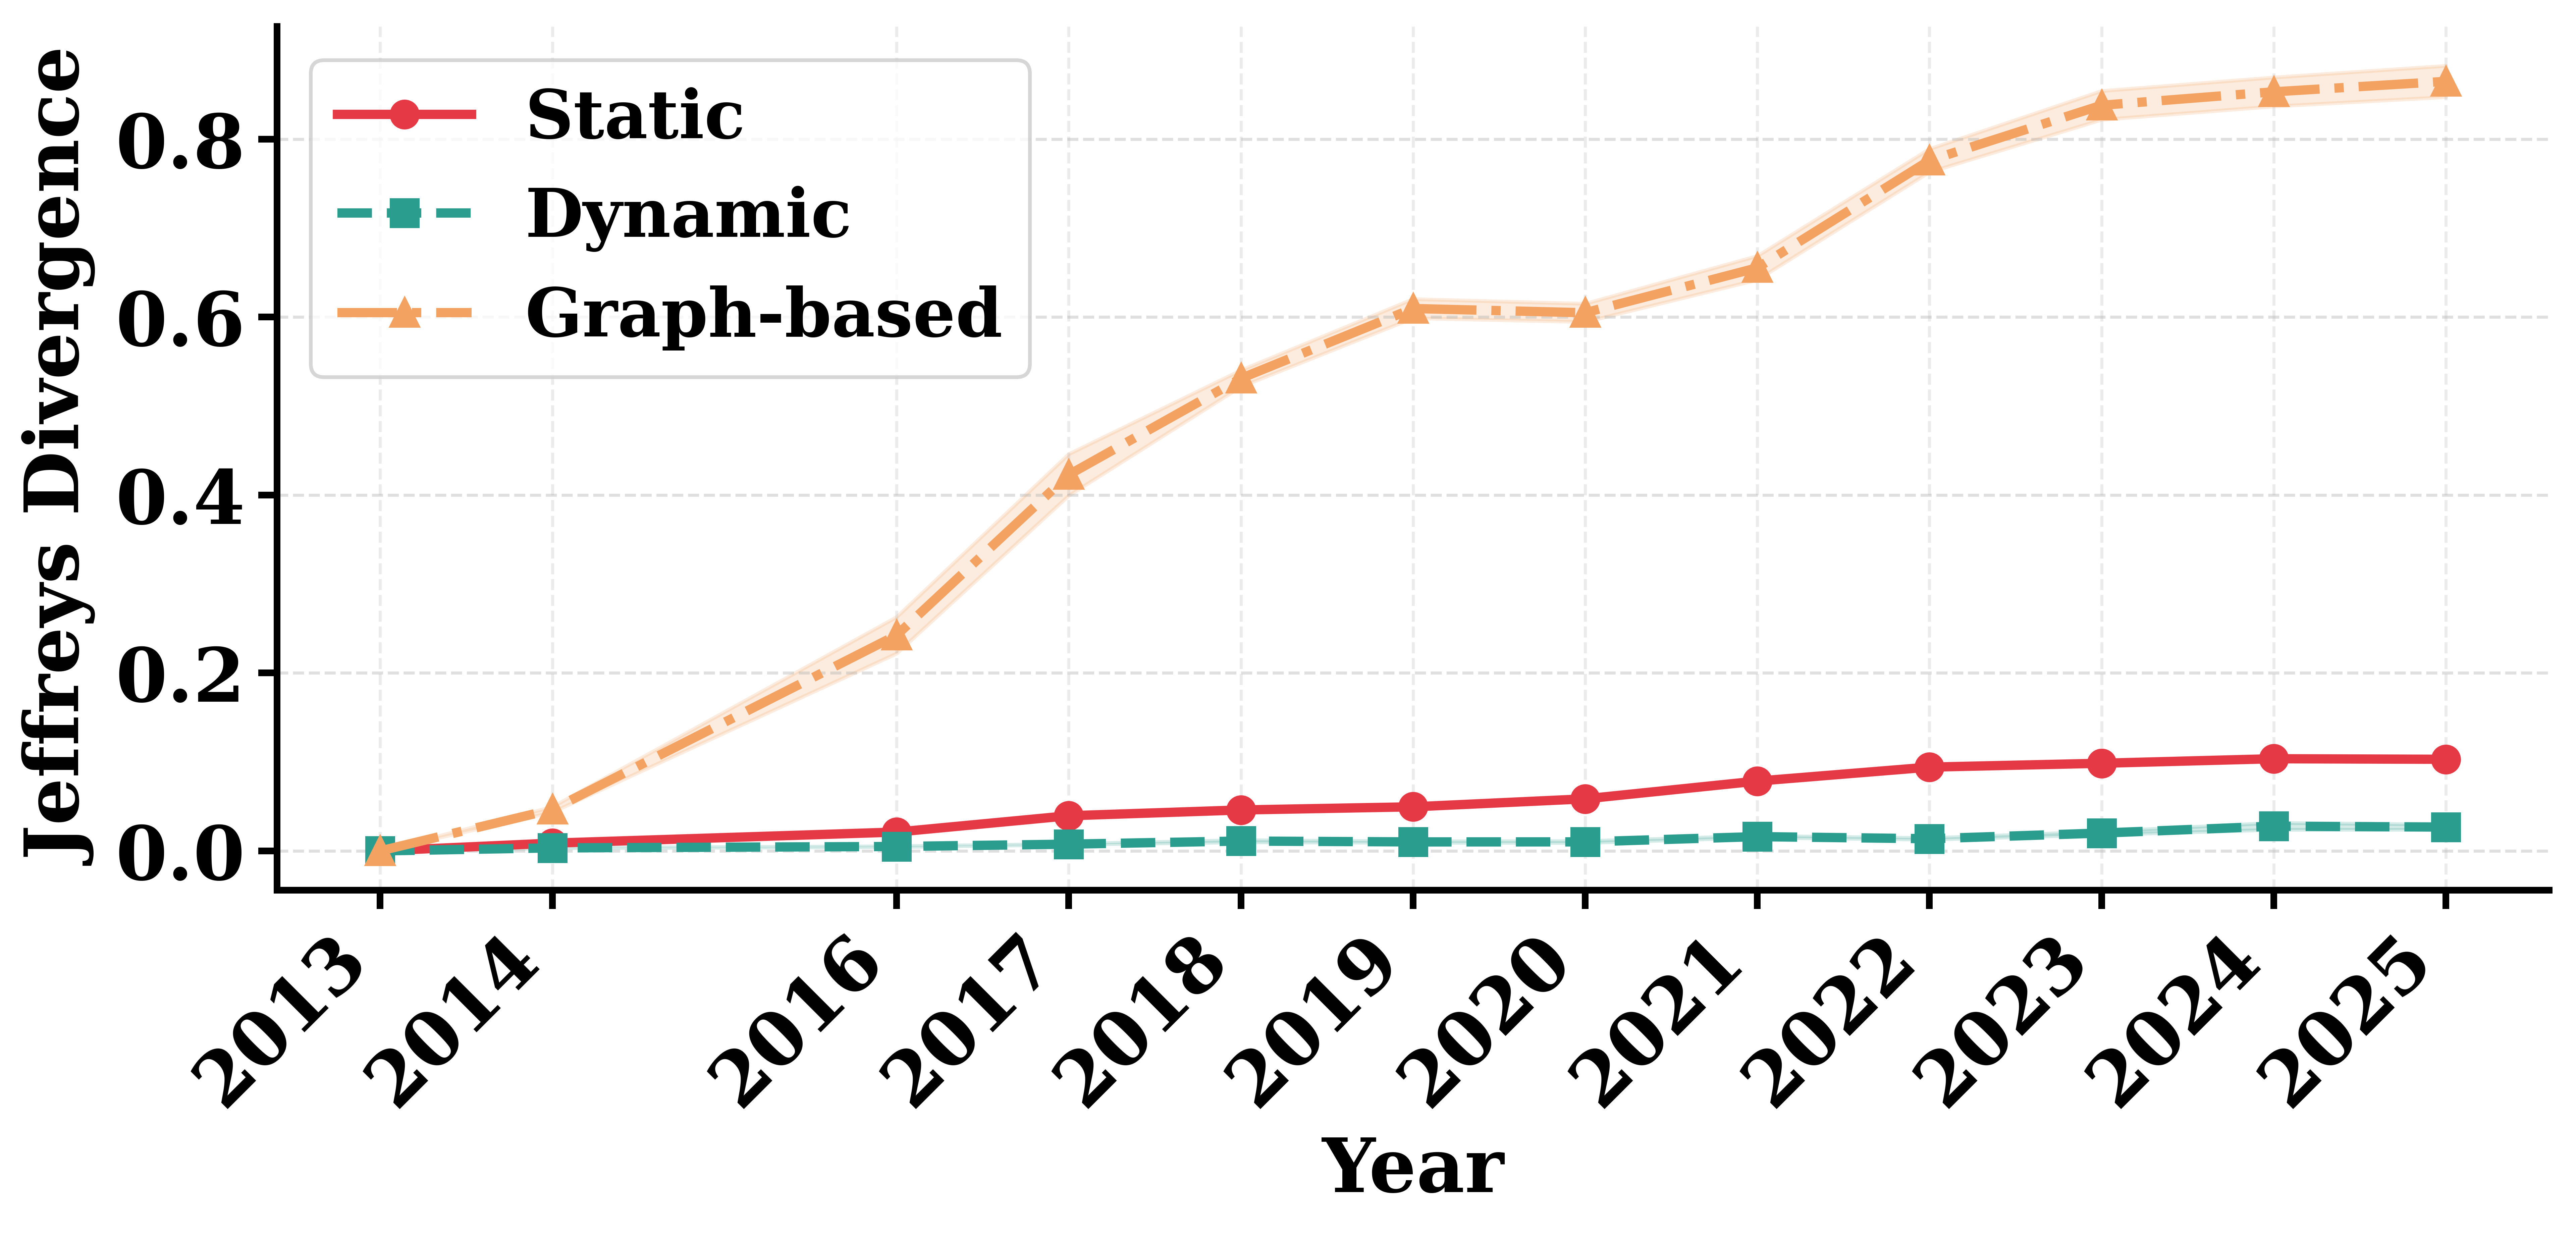

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    "figure.dpi": 800,
    "savefig.dpi": 800,
    "savefig.bbox": "tight",
    "font.family": "serif",
    "font.serif": "DejaVu Serif",
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 18,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "axes.labelweight": "bold",
    "font.weight": "bold",
})

ROOT = Path("benign_v2")

MODALITIES = {
    "data": "Static",
    "json": "Dynamic",
    "gml": "Graph-based"
}

COLORS = {
    "data": "#E63946",
    "json": "#2A9D8F",
    "gml": "#F4A261"
}

MARKERS = {
    "data": "o",
    "json": "s",
    "gml": "^"
}

LINESTYLES = {
    "data": "-",
    "json": "--",
    "gml": "-."
}

def load_runs(modality):
    runs = []
    for i in [1, 2, 3]:
        path = ROOT / f"drift_{modality}_benign_run{i}.csv"
        df = pd.read_csv(path)
        runs.append(df)
    return runs

def compute_stats(runs):
    df_merged = runs[0][["year", "mean_divergence"]].rename(
        columns={"mean_divergence": "run1"}
    )

    for i, df in enumerate(runs[1:], start=2):
        df_merged[f"run{i}"] = df["mean_divergence"]
    df_merged["mean"] = df_merged[[f"run{i}" for i in range(1, 4)]].mean(axis=1)
    df_merged["std"]  = df_merged[[f"run{i}" for i in range(1, 4)]].std(axis=1)

    return df_merged.sort_values("year")
fig, ax = plt.subplots(figsize=(10, 5))

for modality in MODALITIES:
    runs = load_runs(modality)
    stats = compute_stats(runs)
    years = stats["year"]
    mean  = stats["mean"]
    std   = stats["std"]

    ax.plot(
        years,
        mean,
        label=MODALITIES[modality],
        color=COLORS[modality],
        marker=MARKERS[modality],
        linestyle=LINESTYLES[modality],
        linewidth=2.5,
        markersize=7
    )

    ax.fill_between(
        years,
        mean - std,
        mean + std,
        color=COLORS[modality],
        alpha=0.2
    )
ax.set_xlabel("Year")
ax.set_ylabel("Jeffreys Divergence")

ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45, ha="right")

legend = ax.legend()
for text in legend.get_texts():
    text.set_fontweight("bold")

ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for spine in ["left", "bottom"]:
    ax.spines[spine].set_linewidth(1.8)

ax.tick_params(axis="both", width=1.8, length=5)

plt.tight_layout()
plt.savefig("drift_with_shading.pdf")
matplot2tikz.save("benign_figure.tex",flavor="context")
plt.show()